In [ ]:
import pandas as pd
import numpy as np

X_train=pd.read_csv("x_train_final.csv")
y_train=pd.read_csv("y_train_final_j5KGWWK.csv")
X_test=pd.read_csv("x_test_final.csv")

In [ ]:
X_train.shape, y_train.shape, X_test.shape
print(X_train.columns)
print(X_test.columns)
y_train.columns
X_train.isna().sum(axis=0)
X_train.head()
X_train.drop(columns=[ "Unnamed: 0", 'Unnamed: 0.1'], inplace=True)
X_test.drop(columns=["Unnamed: 0"], inplace=True)

Index(['Unnamed: 0.1', 'Unnamed: 0', 'train', 'gare', 'date', 'arret', 'p2q0',
       'p3q0', 'p4q0', 'p0q2', 'p0q3', 'p0q4'],
      dtype='object')
Index(['Unnamed: 0', 'train', 'gare', 'date', 'arret', 'p2q0', 'p3q0', 'p4q0',
       'p0q2', 'p0q3', 'p0q4'],
      dtype='object')


In [ ]:
X_train.head(10)
X_test.head()
       

,train,gare,date,arret,p2q0,p3q0,p4q0,p0q2,p0q3,p0q4
0,ZPQEKP,VXY,2023-11-13,12,0.0,0.0,-2.0,-4.0,-2.0,-4.0
1,KIQSRA,VXY,2023-11-13,12,0.0,0.0,-1.0,1.0,-1.0,0.0
2,QQJYYT,VXY,2023-11-13,12,0.0,1.0,-1.0,1.0,-1.0,1.0
3,FVKYMZ,VXY,2023-11-13,12,0.0,0.0,-1.0,-1.0,0.0,-1.0
4,GXNZBY,AZA,2023-11-13,12,1.0,-2.0,0.0,0.0,0.0,0.0


Time features

In [ ]:
X_train["date"]=pd.to_datetime(X_train["date"])
X_train["dow"]=X_train["date"].dt.day_of_week
X_train["month"]=X_train["date"].dt.month
X_train["woy"]=X_train["date"].dt.isocalendar().week.astype(int)
# X_train["dow_cos"]=np.cos((2*np.pi*X_train["dow"])/7)
# X_train["dow_sin"]=np.sin((2*np.pi*X_train["dow"])/7)
# X_train[["dow", "dow_cos", "dow_sin"]]
#same for test data
X_test["date"]=pd.to_datetime(X_test["date"])
X_test["dow"]=X_test["date"].dt.day_of_week
X_test["month"]=X_test["date"].dt.month
X_test["woy"]=X_test["date"].dt.isocalendar().week.astype(int)
# X_test["dow_cos"]=np.cos((2*np.pi*X_test["dow"])/7)
# X_test["dow_sin"]=np.sin((2*np.pi*X_test["dow"])/7)
# X_test[["dow", "dow_cos", "dow_sin"]]

Lag Features

In [ ]:
X_train["train_lag_mean"] = X_train[["p0q2","p0q3","p0q4"]].mean(axis=1)
X_train["train_lag_std"]  = X_train[["p0q2","p0q3","p0q4"]].std(axis=1)
X_train["train_lag_max"]  = X_train[["p0q2","p0q3","p0q4"]].max(axis=1)
X_train["train_lag_min"]  = X_train[["p0q2","p0q3","p0q4"]].min(axis=1)

X_test["train_lag_mean"] = X_test[["p0q2","p0q3","p0q4"]].mean(axis=1)
X_test["train_lag_std"]  = X_test[["p0q2","p0q3","p0q4"]].std(axis=1)
X_test["train_lag_max"]  = X_test[["p0q2","p0q3","p0q4"]].max(axis=1)
X_test["train_lag_min"]  = X_test[["p0q2","p0q3","p0q4"]].min(axis=1)

In [ ]:
X_train["train_lag_pondere"]=0.5*X_train["p0q2"]+ 0.3*X_train["p0q3"]+0.2*X_train["p0q4"]
X_test["train_lag_pondere"]=0.5*X_test["p0q2"]+ 0.3*X_test["p0q3"]+0.2*X_test["p0q4"]
X_train["S_pondere"]=0.5*X_train["p2q0"]+ 0.3*X_train["p3q0"]+0.2*X_train["p4q0"]
X_test["S_pondere"]=0.5*X_test["p2q0"]+ 0.3*X_test["p3q0"]+0.2*X_test["p4q0"]

In [ ]:
X_train["S_moy"]=X_train[["p2q0", "p3q0", "p4q0"]].mean(axis=1)
X_train["S_std"]=X_train[["p2q0", "p3q0", "p4q0"]].std(axis=1)
X_test["S_moy"]=X_test[["p2q0", "p3q0", "p4q0"]].mean(axis=1)
X_test["S_std"]=X_test[["p2q0", "p3q0", "p4q0"]].std(axis=1)

In [ ]:
X_train["trend_station_1"]=X_train["p2q0"]-X_train["p3q0"]
X_train["trend_station_2"]=X_train["p3q0"]-X_train["p4q0"]
X_test["trend_station_1"]=X_test["p2q0"]-X_test["p3q0"]
X_test["trend_station_2"]=X_test["p3q0"]-X_test["p4q0"]

X_train["trend_train_1"]=X_train["p0q2"]-X_train["p0q3"]
X_train["trend_train_2"]=X_train["p0q3"]-X_train["p0q4"]
X_test["trend_train_1"]=X_test["p0q2"]-X_test["p0q3"]
X_test["trend_train_2"]=X_test["p0q3"]-X_test["p0q4"]


In [ ]:
X_train["train_pos_lag"]=(X_train["train_lag_mean"]>0).astype(int)
X_train["S_pos_moy"]=(X_train["S_moy"]>0).astype(int)
X_test["train_pos_lag"]=(X_test["train_lag_mean"]>0).astype(int)
X_test["S_pos_moy"]=(X_test["S_moy"]>0).astype(int)

In [ ]:
X_train.head()

,train,gare,date,arret,p2q0,p3q0,p4q0,p0q2,p0q3,p0q4,...,train_lag_pondere,S_pondere,S_moy,S_std,trend_station_1,trend_station_2,trend_train_1,trend_train_2,train_pos_lag,S_pos_moy
0,VBXNMF,KYF,2023-04-03,8,0.0,0.0,1.0,-3.0,-1.0,-2.0,...,-2.2,0.2,0.333333,0.57735,0.0,-1.0,-2.0,1.0,0,1
1,VBXNMF,JLR,2023-04-03,9,0.0,0.0,0.0,1.0,0.0,1.0,...,0.7,0.0,0.000000,0.00000,0.0,0.0,1.0,-1.0,1,0
2,VBXNMF,EOH,2023-04-03,10,-1.0,0.0,0.0,-1.0,0.0,0.0,...,-0.5,-0.5,-0.333333,0.57735,-1.0,0.0,-1.0,0.0,0,0
3,VBXNMF,VXY,2023-04-03,11,-1.0,-1.0,0.0,2.0,-2.0,0.0,...,0.4,-0.8,-0.666667,0.57735,0.0,-1.0,4.0,-2.0,0,0
4,VBXNMF,OCB,2023-04-03,12,-1.0,-1.0,-1.0,-1.0,3.0,2.0,...,0.8,-1.0,-1.000000,0.00000,0.0,0.0,-4.0,1.0,1,0


In [ ]:
X_train.groupby("gare")["p2q0"].mean()

gare
ADU   -0.232877
ARX    1.448827
AUW   -0.654047
AVF    0.290459
AVU   -0.165435
         ...   
YWQ   -1.030082
ZAL    0.076626
ZFB   -0.183469
ZHN    0.351250
ZVY    0.358657
Name: p2q0, Length: 84, dtype: float64

In [ ]:
X_train["moy_per_station"]=X_train["gare"].map(X_train.groupby("gare")["p2q0"].mean())
X_test["moy_per_station"]=X_test["gare"].map(X_test.groupby("gare")["p2q0"].mean())

In [ ]:
# catigorecal=["train", "gare", "date", "dow"]
# X_train.drop(columns=catigorecal, inplace=True)
# X_test.drop(columns=catigorecal, inplace=True)



Prepare data for model

In [ ]:
y_train.drop(columns=["Unnamed: 0"], inplace=True)

In [ ]:
X_train["train"]=X_train["train"].astype("category")
X_train["gare"]=X_train["gare"].astype("category")


In [ ]:

X=pd.concat([X_train, y_train], axis=1)
X["train"]=X["train"].astype("category")
X["gare"]=X["gare"].astype("category")
X["date"].dt.month.value_counts()
X=X.sort_values("date", ascending=True)
X["month_"]=X["date"].dt.month

In [ ]:
X_test["train"]=X_test["train"].astype("category")
X_test["gare"]=X_test["gare"].astype("category")

In [ ]:
X_TT=X[X["month_"]<11]
X_VV=X[X["month_"]==11]

In [ ]:
X_TT.drop(columns=["month_", "date"], inplace=True)
X_VV.drop(columns=["month_", "date"], inplace=True)

C:\Users\pc\AppData\Local\Temp\ipykernel_22580\2679085892.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X_TT.drop(columns=["month_", "date"], inplace=True)
C:\Users\pc\AppData\Local\Temp\ipykernel_22580\2679085892.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X_VV.drop(columns=["month_", "date"], inplace=True)


In [ ]:
# catigorecal=[ "date"]

# X_train.drop(columns=catigorecal, inplace=True)
# X_test.drop(columns=catigorecal, inplace=True)

In [ ]:
y_T=X_TT["p0q0"]
X_T=X_TT.drop(columns=["p0q0"])
y_V=X_VV["p0q0"]
X_V=X_VV.drop(columns=["p0q0"])

In [ ]:
X_T.head()

,train,gare,arret,p2q0,p3q0,p4q0,p0q2,p0q3,p0q4,dow,...,S_pondere,S_moy,S_std,trend_station_1,trend_station_2,trend_train_1,trend_train_2,train_pos_lag,S_pos_moy,moy_per_station
0,VBXNMF,KYF,8,0.0,0.0,1.0,-3.0,-1.0,-2.0,0,...,0.2,0.333333,0.577350,0.0,-1.0,-2.0,1.0,0,1,0.410364
5309,EVCECW,ZFB,21,0.0,-1.0,0.0,0.0,1.0,0.0,0,...,-0.3,-0.333333,0.577350,1.0,-1.0,-1.0,1.0,1,0,-0.183469
5308,EVCECW,AUW,20,-1.0,0.0,-1.0,1.0,0.0,1.0,0,...,-0.7,-0.666667,0.577350,-1.0,1.0,1.0,-1.0,1,0,-0.654047
5307,EVCECW,YWQ,19,0.0,-1.0,-1.0,0.0,1.0,0.0,0,...,-0.5,-0.666667,0.577350,1.0,0.0,-1.0,1.0,1,0,-1.030082
5306,EVCECW,MZE,18,-1.0,-1.0,1.0,-2.0,0.0,0.0,0,...,-0.6,-0.333333,1.154701,0.0,-2.0,-2.0,0.0,0,0,-0.502368


In [ ]:
X_test.drop(columns=["date"], inplace=True)

In [ ]:
X_T.shape, y_T.shape, X_V.shape, y_V.shape, X_test.shape, X_train.shape

((629579, 27), (629579,), (37685, 27), (37685,), (20657, 27), (667264, 28))

In [ ]:
y_T_sign_1=(y_T>=0).astype(int)
y_T_module_1=abs(y_T)

y_V_sign_1=(y_V>=0).astype(int)
y_V_module_1=abs(y_V)


In [ ]:
A=(y_train>=0).astype(int)
b=A.value_counts().sum()
A.value_counts()/b

p0q0
1       0.706621
0       0.293379
Name: count, dtype: float64

DATA for classifier

In [ ]:
X_T_sign_1=X_T.copy()
X_V_sign_1=X_V.copy()
X_T_sign_1["sign_p2q0"]=(X_T_sign_1["p2q0"]>=0).astype(int)
X_T_sign_1["sign_p3q0"]=(X_T_sign_1["p3q0"]>=0).astype(int)
X_T_sign_1["sign_p4q0"]=(X_T_sign_1["p4q0"]>=0).astype(int)
X_T_sign_1["proba_per_station_pondere"]=0.5*X_T_sign_1["sign_p2q0"]+0.3*X_T_sign_1["sign_p3q0"]+0.2*X_T_sign_1["sign_p4q0"]
X_T_sign_1["probability_no_delay_p2q0"]=X_T_sign_1.groupby(["gare"])["sign_p2q0"].transform("mean")

X_V_sign_1["sign_p2q0"]=(X_V_sign_1["p2q0"]>=0).astype(int)
X_V_sign_1["sign_p3q0"]=(X_V_sign_1["p3q0"]>=0).astype(int)
X_V_sign_1["sign_p4q0"]=(X_V_sign_1["p4q0"]>=0).astype(int)
X_V_sign_1["proba_per_station_pondere"]=0.5*X_V_sign_1["sign_p2q0"]+0.3*X_V_sign_1["sign_p3q0"]+0.2*X_V_sign_1["sign_p4q0"]
X_V_sign_1["probability_no_delay_p2q0"]=X_V_sign_1.groupby(["gare"])["sign_p2q0"].transform("mean")

C:\Users\pc\AppData\Local\Temp\ipykernel_12552\3678315202.py:7: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  X_T_sign_1["probability_no_delay_p2q0"]=X_T_sign_1.groupby(["gare"])["sign_p2q0"].transform("mean")
C:\Users\pc\AppData\Local\Temp\ipykernel_12552\3678315202.py:13: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  X_V_sign_1["probability_no_delay_p2q0"]=X_V_sign_1.groupby(["gare"])["sign_p2q0"].transform("mean")


In [ ]:
X_T_sign_1.drop(columns=["train_lag_max", "train_lag_std", "train_lag_min", "p0q2", "p0q4", "dow", "p0q3", "trend_train_1", "trend_train_2", "sign_p4q0", "S_pos_moy", "sign_p2q0"], inplace=True)
X_V_sign_1.drop(columns=["train_lag_max", "train_lag_std", "train_lag_min", "p0q2", "p0q4", "dow", "p0q3", "trend_train_1", "trend_train_2", "sign_p4q0", "S_pos_moy", "sign_p2q0"], inplace=True)

In [ ]:
X_T_sign_1.shape, y_T_sign_1.shape, X_V_sign_1.shape, y_V_sign_1.shape

((629579, 20), (629579,), (37685, 20), (37685,))

In [ ]:
from imblearn.over_sampling import SMOTENC
# 1. On identifie automatiquement les colonnes 'category'
cat_mask = X.dtypes == 'category'

# 2. On lance SMOTE-NC
# 'categorical_features' peut prendre une liste de booléens (le masque)
smote_nc = SMOTENC(categorical_features=cat_mask, random_state=42)
X_res, y_res = smote_nc.fit_resample(X_T_sign_1, y_T_sign_1)

ValueError: The truth value of a Series is ambiguous. Use a.empty, a.bool(), a.item(), a.any() or a.all().

DATA for regressor

In [ ]:
X_T_module_1=X_T
X_V_model_1=X_V

In [ ]:
X_T_module_1.shape, y_T_module_1.shape, X_V_model_1.shape, y_V_module_1.shape

((629579, 27), (629579,), (37685, 27), (37685,))

MODELS

In [ ]:
from sklearn.metrics import mean_absolute_error
from sklearn.linear_model import LinearRegression
model_1=LinearRegression()
model_1.fit(X_train, y_train)

y_pred_1=model_1.predict(X_train)
MSE_1=mean_absolute_error(np.round(y_pred_1), y_train)
print("MSE_1", MSE_1)

KeyboardInterrupt: 

In [ ]:
from sklearn.linear_model import Ridge
from sklearn.model_selection import GridSearchCV
model_2=Ridge(random_state=42)
grid=GridSearchCV(estimator=model_2, param_grid={"alpha":[1, 2, 5, 10, 15]}, scoring="neg_mean_squared_error")
grid.fit(X_train, y_train)
print(grid.best_params_)
model_22=Ridge(random_state=42, alpha=15)
model_22.fit(X_train, y_train)
y_pred=model_22.predict(X_test)

y_pred_2=model_22.predict(X_train)
MSE_2=mean_absolute_error(np.round(y_pred_2), y_train)
print("MSE_2", MSE_2)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Ridge(random_state=42)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'alpha': [1, 2, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'neg_mean_squared_error'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",None
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displayed;- >2 : the score is also displayed;- >3 : the fold and candi

In [ ]:
import torch 
import torch.nn as nn
import torch.optim as optim

input_size=X_train.shape[1]
model=nn.Sequential(
    nn.Linear(input_size, 64),
    nn.ReLU(),
    nn.Linear(64, 32), 
    nn.ReLU(),
    nn.Linear(32, 1)
)

criterion=nn.L1Loss()
optimizer=optim.Adam(model.parameters(), lr=0.001)

X_tensor = torch.tensor(X_train.values, dtype=torch.float32)
y_tensor = torch.tensor(y_train.values, dtype=torch.float32).view(-1, 1)
n=400
for epoch in range(n):
    outputs=model(X_tensor)
    loss=criterion(y_tensor, outputs)
    # Backward pass and optimization
    optimizer.zero_grad()
    
    loss.backward()
    optimizer.step()# Backward pass and optimization
    if (epoch + 1) % 20 == 0:
        print(f'Epoch [{epoch+1}/100], Loss: {loss.item():.4f}')

y_pred_nn=torch.round(model(X_tensor)).detach().cpu().numpy()
MSE_nn=mean_absolute_error(y_pred_nn, y_train)
print("MSE_nn", MSE_nn)

y_pred_nn=torch.round(model(X_tensor)).detach().cpu().numpy()
MSE_nn=mean_absolute_error(y_pred_nn, y_train)
print("MSE_nn", MSE_nn)

Epoch [20/100], Loss: 0.8871
Epoch [40/100], Loss: 0.8756
Epoch [60/100], Loss: 0.8662
Epoch [80/100], Loss: 0.8553
Epoch [100/100], Loss: 0.8444
Epoch [120/100], Loss: 0.8349
Epoch [140/100], Loss: 0.8262
Epoch [160/100], Loss: 0.8180
Epoch [180/100], Loss: 0.8102
Epoch [200/100], Loss: 0.8046
Epoch [220/100], Loss: 0.8020
Epoch [240/100], Loss: 0.8004
Epoch [260/100], Loss: 0.7979
Epoch [280/100], Loss: 0.7981
Epoch [300/100], Loss: 0.7956
Epoch [320/100], Loss: 0.7998
Epoch [340/100], Loss: 0.7947
Epoch [360/100], Loss: 0.7937
Epoch [380/100], Loss: 0.7927
Epoch [400/100], Loss: 0.7921


In [ ]:
import lightgbm as lgb
from sklearn.metrics import mean_absolute_error

In [ ]:


# Create dataset
train_data = lgb.Dataset(X_T, label=y_T)
valid_data = lgb.Dataset(X_V, label=y_V)

# Parameters
params = { "objective": "regression_l1", "metric": "mae", "learning_rate": 0.02, "num_leaves": 255, "min_data_in_leaf": 30, "feature_fraction": 0.9, "bagging_fraction": 0.9, "bagging_freq": 1, "lambda_l1": 0.5, "lambda_l2": 0.5, "verbose": -1 }
# Train
model = lgb.train(
    
    params,
    
    train_data,
    valid_sets=[valid_data],
    num_boost_round=2000,
    callbacks=[lgb.early_stopping(100)]
)




Training until validation scores don't improve for 100 rounds
Early stopping, best iteration is:
[1292]	valid_0's l1: 0.731779


In [ ]:
import joblib
joblib.dump(model, 'models/model_lgb.pkl')

['models/model_lgb.pkl']

In [ ]:
y_rounded=np.round(model.predict(X_V))
mae=mean_absolute_error(y_rounded, y_V)
print("mae", mae)

mae 0.7172615098845695


<Axes: title={'center': 'Feature importance'}, xlabel='Feature importance', ylabel='Features'>

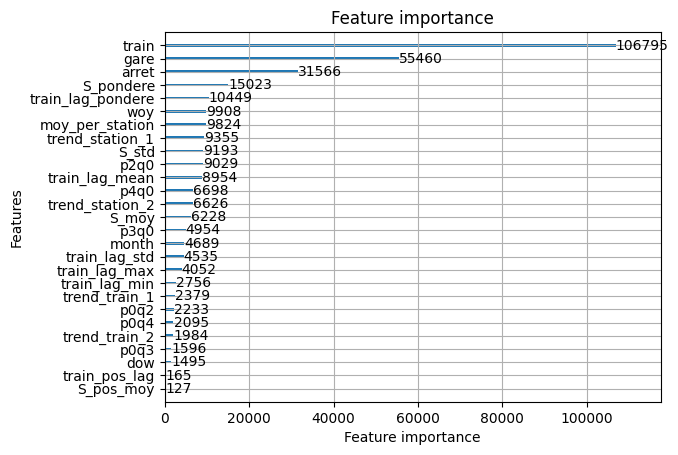

In [ ]:
lgb.plot_importance(model, max_num_features=30)

In [ ]:
from sklearn.model_selection import RandomizedSearchCV
model_lgb=lgb.LGBMRegressor(objective="regression_l1")
param_grid = {
    'num_leaves': np.arange(20, 200, 10),
    'max_depth': [-1, 5, 10, 20, 30],
    'learning_rate': np.linspace(0.01, 0.2, 20),
    'n_estimators': np.arange(200, 1500, 200),
    'subsample': np.linspace(0.6, 1.0, 5),
    'colsample_bytree': np.linspace(0.6, 1.0, 5),
    'min_child_samples': np.arange(5, 100, 10),
    'lambda_l1': np.linspace(0, 5, 10),
    'lambda_l2': np.linspace(0, 5, 10)
}
rs=RandomizedSearchCV(estimator=model_lgb, param_distributions=param_grid,
    n_iter=50,
    scoring='neg_mean_absolute_error',  # ⚠️ important
    cv=5,
    verbose=1,


    n_jobs=-1
)
rs.fit(X_train, y_train)

print("Best params:",rs.best_params_)



Classifier(sign) / regression(module)

In [ ]:
#Classifier
# Create dataset
train_data_class = lgb.Dataset(X_T_sign_1, label=y_T_sign_1)
valid_data_class = lgb.Dataset(X_V_sign_1, label=y_V_sign_1)

# Parameters
params = { "objective": "binary", "metric": "binary_logloss", "learning_rate": 0.02, "num_leaves": 255, "min_data_in_leaf": 30, "feature_fraction": 0.9, "bagging_fraction": 0.9, "bagging_freq": 1, "lambda_l1": 0.5, "lambda_l2": 0.5, "verbose": -1 }
# Train
model_class = lgb.train(
    
    params,
    
    train_data_class,
    valid_sets=[valid_data_class],
    num_boost_round=2000,
    callbacks=[lgb.early_stopping(100)]
)



Training until validation scores don't improve for 100 rounds
Early stopping, best iteration is:
[228]	valid_0's binary_logloss: 0.391096


In [ ]:
from sklearn.metrics import confusion_matrix, f1_score, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

In [ ]:
y_class=model_class.predict(X_V_sign_1)
y_class=(y_class>0.7).astype(int)

f1score 0.8534309810872402


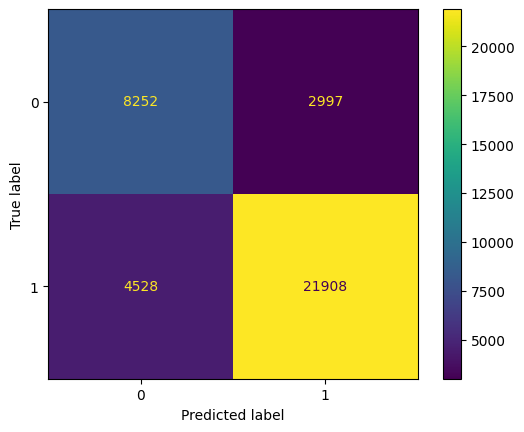

In [ ]:
F1=f1_score(y_V_sign_1, y_class)
conf=confusion_matrix(y_V_sign_1, y_class)
disp=ConfusionMatrixDisplay(confusion_matrix=conf)
disp.plot()
print("f1score", F1)

<Axes: title={'center': 'Feature importance'}, xlabel='Feature importance', ylabel='Features'>

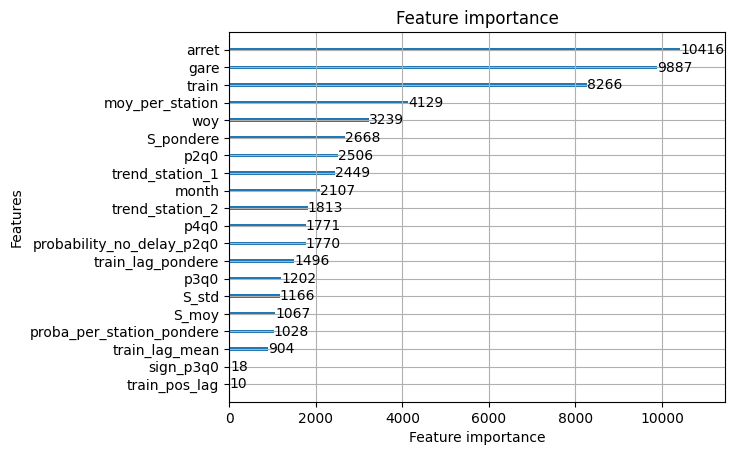

In [ ]:
lgb.plot_importance(model_class, max_num_features=30)

In [ ]:
#Regresser


# Create dataset
train_data_regr = lgb.Dataset(X_T_module_1, label=y_T_module_1)
valid_data_regr = lgb.Dataset(X_V_model_1, label=y_V_module_1)

# Parameters
params = { "objective": "regression_l1", "metric": "mae", "learning_rate": 0.02, "num_leaves": 255, "min_data_in_leaf": 30, "feature_fraction": 0.9, "bagging_fraction": 0.9, "bagging_freq": 1, "lambda_l1": 0.5, "lambda_l2": 0.5, "verbose": -1 }
# Train
model_regr = lgb.train(
    
    params,
    
    
    train_data_regr,
    valid_sets=[valid_data_regr],
    num_boost_round=2000,
    callbacks=[lgb.early_stopping(100)]
)
y_regr=model_regr.predict(X_V_model_1)
y_regr



Training until validation scores don't improve for 100 rounds
Did not meet early stopping. Best iteration is:
[1995]	valid_0's l1: 0.666272


array([0.98057939, 0.93906297, 1.06946689, ..., 1.01760151, 1.01860408,
       0.96831685])

In [ ]:
y_class[y_class==-1].shape

(12780,)

In [ ]:
y_class=np.where(y_class==0, -1, 1)

In [ ]:
#Ensembling



y_predict=y_class*y_regr
mae=mean_absolute_error(y_predict, y_V)
print("mae:", mae)

mae: 0.7754209071041185


In [ ]:
y_predict

array([ 0.98057939,  0.93906297,  1.06946689, ...,  1.01760151,
       -1.01860408, -0.96831685])

In [ ]:
X_test_class_1=X_test.copy()
X_test_class_1["sign_p2q0"]=(X_test_class_1["p2q0"]>=0).astype(int)
X_test_class_1["sign_p3q0"]=(X_test_class_1["p3q0"]>=0).astype(int)
X_test_class_1["sign_p4q0"]=(X_test_class_1["p4q0"]>=0).astype(int)
X_test_class_1["proba_per_station_pondere"]=0.5*X_test_class_1["sign_p2q0"]+0.3*X_test_class_1["sign_p3q0"]+0.2*X_test_class_1["sign_p4q0"]
X_test_class_1["probability_no_delay_p2q0"]=X_test_class_1.groupby(["gare"])["sign_p2q0"].transform("mean")

X_test_class_1.drop(columns=["train_lag_max", "train_lag_std", "train_lag_min", "p0q2", "p0q4", "dow", "p0q3", "trend_train_1", "trend_train_2", "sign_p4q0", "S_pos_moy", "sign_p2q0"], inplace=True)
X_test_regr=X_test.copy()

C:\Users\pc\AppData\Local\Temp\ipykernel_15916\460013711.py:6: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  X_test_class_1["probability_no_delay_p2q0"]=X_test_class_1.groupby(["gare"])["sign_p2q0"].transform("mean")


In [ ]:
y_final_class=model_class.predict(X_test_class_1)
y_final_class=(y_final_class>0.7).astype(int)
y_final_class=np.where(y_final_class==0, -1, 1)
y_final_reg=model_regr.predict(X_test_regr)

In [ ]:
y_final=pd.DataFrame(np.round(y_final_reg*y_final_class), columns=["p0q0"])

y_final.to_csv("submission11.csv", index=True)

